# Tema 3 · NLP — Análisis de Sentimientos Financieros
## Demo del viernes (resuelto) · Dataset: **Financial PhraseBank**

**Caso de negocio.** Un equipo de inversión/research quiere clasificar
automáticamente el **sentimiento** (positivo / neutral / negativo) de noticias y
titulares financieros, para usarlo como **señal adicional** en su análisis de
mercado.

Construiremos un clasificador de texto clásico y reproducible sin GPU:
**limpieza → TF-IDF → clasificador (Naive Bayes / Logística)**.

Pipeline de la demo:
1. Carga y exploración (distribución de clases, longitud de textos)
2. Preprocesamiento de texto (limpieza, stopwords, lematización)
3. Vectorización con TF-IDF
4. Entrenamiento (Naive Bayes y Regresión Logística)
5. Evaluación (F1 macro, matriz de confusión)
6. Análisis cualitativo de errores
7. Conclusión de negocio


## 0. Semilla personal (anti-copia) y recursos NLTK

Definimos la cédula como semilla y descargamos los recursos de NLTK. Incluimos un
**workaround de SSL** frecuentemente necesario en macOS.

In [1]:
cedula = 1020304050  # <-- reemplaza por tu número de cédula
import numpy as np
np.random.seed(cedula)

import ssl, nltk
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except Exception:
    pass
for r in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(r, quiet=True)
print("Semilla:", cedula, "| recursos NLTK listos")

Semilla: 1020304050 | recursos NLTK listos


## 1. Carga y exploración

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../../data/04-nlp/financial_phrasebank.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (2264, 2)


,Sentence,Sentiment
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [3]:
df = df.sample(frac=0.85, random_state=cedula).reset_index(drop=True)
print("Dimensiones tras el muestreo:", df.shape)

Dimensiones tras el muestreo: (1924, 2)


### Distribución de clases
En noticias financieras la clase **neutral** suele ser mayoritaria → el problema
está **desbalanceado** (lo tendremos en cuenta con la métrica F1 macro).

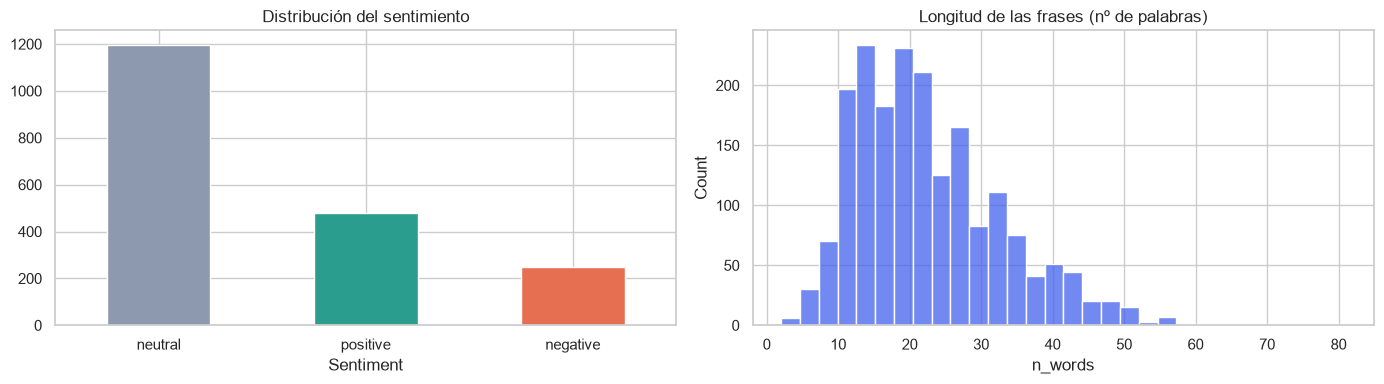

Sentiment
neutral     0.623
positive    0.248
negative    0.129
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["Sentiment"].value_counts().plot(kind="bar", ax=axes[0],
        color=["#8d99ae", "#2a9d8f", "#e76f51"])
axes[0].set_title("Distribución del sentimiento"); axes[0].tick_params(axis="x", rotation=0)

df["n_words"] = df["Sentence"].str.split().apply(len)
sns.histplot(df["n_words"], bins=30, ax=axes[1], color="#4361ee")
axes[1].set_title("Longitud de las frases (nº de palabras)")
plt.tight_layout(); plt.show()

print(df["Sentiment"].value_counts(normalize=True).round(3))

## 2. Preprocesamiento de texto

Pipeline clásico de NLP:
- **Lowercasing** y eliminación de puntuación/números.
- **Tokenización** (partir en palabras).
- Quitar **stopwords** (palabras vacías) y palabras muy cortas.
- **Lematización** (reducir a la raíz: *growing → grow*).

In [5]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)         # solo letras
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop and len(t) > 2]
    return " ".join(tokens)

df["clean"] = df["Sentence"].apply(clean_text)
df[["Sentence", "clean"]].head(3)

,Sentence,clean
0,No service pricing details were disclosed .,service pricing detail disclosed
1,Cramo is a service company specialising in con...,cramo service company specialising constructio...
2,Finnish power supply solutions and systems pro...,finnish power supply solution system provider ...


### Separar X e y, y hacer el split
Estratificamos por la clase para conservar las proporciones.

In [6]:
from sklearn.model_selection import train_test_split

X = df["clean"]
y = df["Sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=cedula
)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 1443 | Test: 481


## 3. Vectorización con TF-IDF

TF-IDF pondera cada palabra por su frecuencia en el documento y su rareza en el
corpus. Usamos unigramas y bigramas y limitamos el vocabulario a los términos más
frecuentes.

> Importante: el `TfidfVectorizer` se ajusta **solo con el train** (dentro del
> pipeline) para evitar fuga de datos.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=5000)
# ajuste ilustrativo (el pipeline lo reajustará solo con train)
_ = vectorizer.fit(X_train)
print("Tamaño del vocabulario:", len(vectorizer.vocabulary_))

Tamaño del vocabulario: 1574


## 4. Entrenamiento de modelos

Dos clasificadores clásicos sobre el TF-IDF, encapsulados en un `Pipeline`:
- **Naive Bayes multinomial** — rápido y sólido en texto.
- **Regresión logística** — interpretable (peso de cada palabra), con
  `class_weight="balanced"` por el desbalance.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

def make_pipe(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=5000)),
        ("clf", clf),
    ])

nb_model = make_pipe(MultinomialNB())
lr_model = make_pipe(LogisticRegression(max_iter=1000, class_weight="balanced",
                                        random_state=cedula))
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
print("Modelos entrenados.")

Modelos entrenados.


## 5. Evaluación

Con clases desbalanceadas, reportamos el **F1 macro** (promedia las clases sin
ponderar por tamaño) además del reporte por clase.

In [9]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

for name, model in [("Naive Bayes", nb_model), ("Regresión Logística", lr_model)]:
    pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, pred))
    print("F1 macro:", round(f1_score(y_test, pred, average="macro"), 3))


===== Naive Bayes =====
              precision    recall  f1-score   support

    negative       0.82      0.37      0.51        62
     neutral       0.87      0.98      0.92       300
    positive       0.70      0.68      0.69       119

    accuracy                           0.83       481
   macro avg       0.80      0.68      0.71       481
weighted avg       0.82      0.83      0.81       481

F1 macro: 0.707

===== Regresión Logística =====
              precision    recall  f1-score   support

    negative       0.65      0.68      0.66        62
     neutral       0.92      0.94      0.93       300
    positive       0.79      0.72      0.75       119

    accuracy                           0.85       481
   macro avg       0.78      0.78      0.78       481
weighted avg       0.85      0.85      0.85       481

F1 macro: 0.781


### 5.1 Matriz de confusión (mejor modelo)

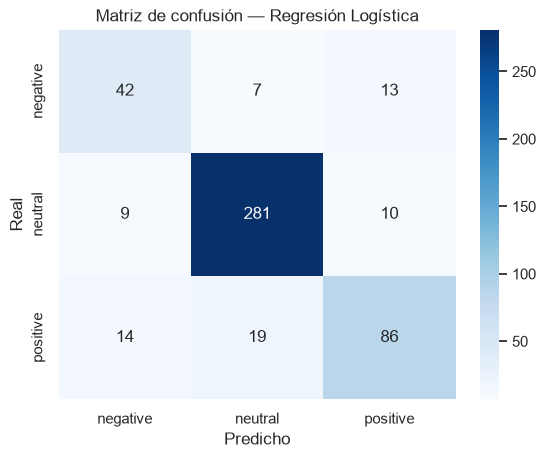

In [10]:
best = lr_model
pred = best.predict(X_test)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.title("Matriz de confusión — Regresión Logística")
plt.show()

### 5.2 Palabras más asociadas a cada sentimiento
De la logística podemos leer qué términos empujan hacia cada clase.

In [11]:
import numpy as np
vec = best.named_steps["tfidf"]
clf = best.named_steps["clf"]
feat = np.array(vec.get_feature_names_out())
for i, cls in enumerate(clf.classes_):
    top = np.argsort(clf.coef_[i])[-10:][::-1]
    print(f"{cls:>9}: {', '.join(feat[top])}")

 negative: decreased, fell, dropped, decreased eur, lower, passenger, slipped, margin, operating margin, profit
  neutral: value, approximately, includes, service, total, disclosed, include, finland, development, people
 positive: increased, increase, rose, grew, improved, awarded, rose eur, finnish, year, said


## 6. Análisis cualitativo de errores

Revisamos algunas frases mal clasificadas: suelen fallar por **negaciones**,
**ironía** o **jerga financiera**.

In [12]:
test_df = pd.DataFrame({"texto": X_test, "real": y_test, "pred": pred})
errores = test_df[test_df["real"] != test_df["pred"]]
print("Errores:", len(errores), "de", len(test_df))
for _, r in errores.head(6).iterrows():
    print(f"\n[real={r['real']} | pred={r['pred']}]  {r['texto'][:120]}")

Errores: 72 de 481

[real=neutral | pred=negative]  report full year result august

[real=negative | pred=positive]  repeat see operating profit reporting helsinki newsroom keywords tecnomen result

[real=negative | pred=neutral]  samsung currently occupies third place lost ground quarter dropping share overall

[real=positive | pred=neutral]  fair value property portfolio doubled result kapiteeli acquisition totalled eur million

[real=neutral | pred=negative]  passenger tunnel expected put operation

[real=neutral | pred=negative]  goodwill intangible asset account mln euro mln purchase price pct payable aspo share


## 7. Conclusión de negocio

- El modelo TF-IDF + Logística alcanza un **F1 macro** razonable como *baseline*
  reproducible sin GPU; la clase **neutral** (mayoritaria) es la más fácil, y la
  **negativa** (minoritaria) la más difícil.
- Los errores se concentran en frases con **negación, ironía o jerga**: TF-IDF no
  captura contexto ni orden de palabras.
- **Confiabilidad como señal:** útil como *una* señal más dentro del análisis,
  no como decisión automática. Conviene combinarla con otras fuentes y validar en
  el tiempo.

**Siguiente nivel:** *word embeddings* o modelos preentrenados (BERT / **FinBERT**)
capturan contexto y suelen mejorar, a costa de más cómputo.
